# PGBM hyperparameter tuning

In [1]:
# Load data

import pandas as pd
import numpy as np 

train_df = pd.read_parquet("data/train_data.parquet")

train_df.index = pd.to_numeric(train_df.index, errors="coerce")

cols_to_drop = ["issue_d", "earliest_cr_line"]
train_df = train_df.drop(columns=cols_to_drop, errors="ignore")

In [2]:
# Separate features and targets

train_full_X = train_df.drop(["target", "target_annual_roi"], axis=1)
train_full_y_cat = train_df["target"]
train_full_y_reg = train_df["target_annual_roi"]

# Drop datetime features from the feature set

cols_to_drop = ["issue_d", "earliest_cr_line"]
train_full_X = train_full_X.drop(columns=cols_to_drop, errors="ignore")

In [3]:
# Create subsets of the data for different training sizes - chronplogical order is preserved, so we take the last N rows for each subset

train_1k_X = train_full_X.tail(1000)
train_1k_y_cat = train_full_y_cat.tail(1000)
train_1k_y_reg = train_full_y_reg.tail(1000)

train_10k_X = train_full_X.tail(10000)
train_10k_y_cat = train_full_y_cat.tail(10000)
train_10k_y_reg = train_full_y_reg.tail(10000)

train_100k_X = train_full_X.tail(100000)
train_100k_y_cat = train_full_y_cat.tail(100000)
train_100k_y_reg = train_full_y_reg.tail(100000)

In [4]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

cols_to_nominal_cat = train_df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:")
for col in cols_to_nominal_cat:
    print(f"- {col}")

cardinality = train_df[cols_to_nominal_cat].nunique()
threshold_for_ohe = 5

cols_for_ohe = cardinality[cardinality <= threshold_for_ohe].index.tolist()
cols_for_te = cardinality[cardinality > threshold_for_ohe].index.tolist()

ohe_categories = []
for col in cols_for_ohe:
    unique_cats = train_df[col].dropna().unique().tolist()
    ohe_categories.append(unique_cats)

ohe_transformer = OneHotEncoder(
    categories=ohe_categories, 
    drop="if_binary", 
    handle_unknown="ignore", 
    sparse_output=False
)

target_transformer_nominal = TargetEncoder(target_type="continuous", smooth="auto")

numeric_preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", ohe_transformer, cols_for_ohe),
        ("target_enc", target_transformer_nominal, cols_for_te)
    ],
    remainder="passthrough", 
    verbose_feature_names_out=False
).set_output(transform="pandas")

imputed_numeric_preprocessor = make_pipeline(
    numeric_preprocessor,
    SimpleImputer(strategy="median")
).set_output(transform="pandas")

gbdt_preprocessor = "passthrough"

Categorical columns:
- home_ownership
- verification_status
- purpose
- addr_state
- initial_list_status
- application_type
- disbursement_method


## Regression

[Parameters](https://pgbm.readthedocs.io/en/latest/parameters_sklearn.html)

### 1k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble


# Parameter tuning settings

timeout_seconds = 60*60*0.5
no_improvement_trials = 100

# Split the 1k dataset to evaluate on holdout after tuning
# Had problem with overfitting and extreme bad results on last 200 rows so switched the order

X_tuning = train_1k_X.tail(800)
y_tuning = train_1k_y_reg.tail(800)
X_val_holdout = train_1k_X.head(200)
y_val_holdout = train_1k_y_reg.head(200)

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 8), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        preds_dist = full_pipeline.named_steps['histgradientboostingregressor'].sample(preds_point, preds_std, n_estimates=1000)
        
        crps = crps_ensemble(preds_dist, y_val.values)
        cv_scores.append(crps)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST CRPS: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_1k_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_1k_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_1k_parallel.html")


[I 2026-04-25 12:04:28,511] A new study created in memory with name: no-name-8b144066-315c-4f2e-8a71-a0342029f007
/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktická část/Github/bachelor_thesis/.venv/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktická část/Github/bachelor_thesis/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
[I 2026-04-25 12:04:36,016] Trial 2 finished with value: 0.19481312059445208 and parameters: {'max_iter': 142, 'learning_rate': 0.18014227325950968, 'max_depth': 3, 'min_samples_leaf': 97, 'max_leaf_nodes': 17, 'l2_regular


BEST CRPS: 0.1818
BEST PARAMETERS:
best_params = {
    "max_iter": 713,
    "learning_rate": 0.052455549685375094,
    "max_depth": 6,
    "min_samples_leaf": 100,
    "max_leaf_nodes": 15,
    "l2_regularization": 0.026055305297547952,
    "max_bins": 233,
    "tree_correlation": 0.0002975059780494224,
    "distribution": "laplace",
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.3001
  tree_correlation    : 0.2867
  max_depth           : 0.1014
  max_bins            : 0.0946
  max_leaf_nodes      : 0.0765
  max_iter            : 0.0515
  distribution        : 0.0465
  l2_regularization   : 0.0220
  min_samples_leaf    : 0.0207


In [6]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val CRPS:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)


BEST PARAMS: {'max_iter': 713, 'learning_rate': 0.052455549685375094, 'max_depth': 6, 'min_samples_leaf': 100, 'max_leaf_nodes': 15, 'l2_regularization': 0.026055305297547952, 'max_bins': 233, 'tree_correlation': 0.0002975059780494224, 'distribution': 'laplace', 'random_state': 42, 'verbose': 0, 'with_variance': True}


/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktická část/Github/bachelor_thesis/.venv/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktická část/Github/bachelor_thesis/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktická část/Github/bachelor_thesis/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktick


Optuna Val CRPS:   0.1818
Holdout Test CRPS: 0.1982
Holdout Test RMSE: 0.3529


/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktická část/Github/bachelor_thesis/.venv/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktická část/Github/bachelor_thesis/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


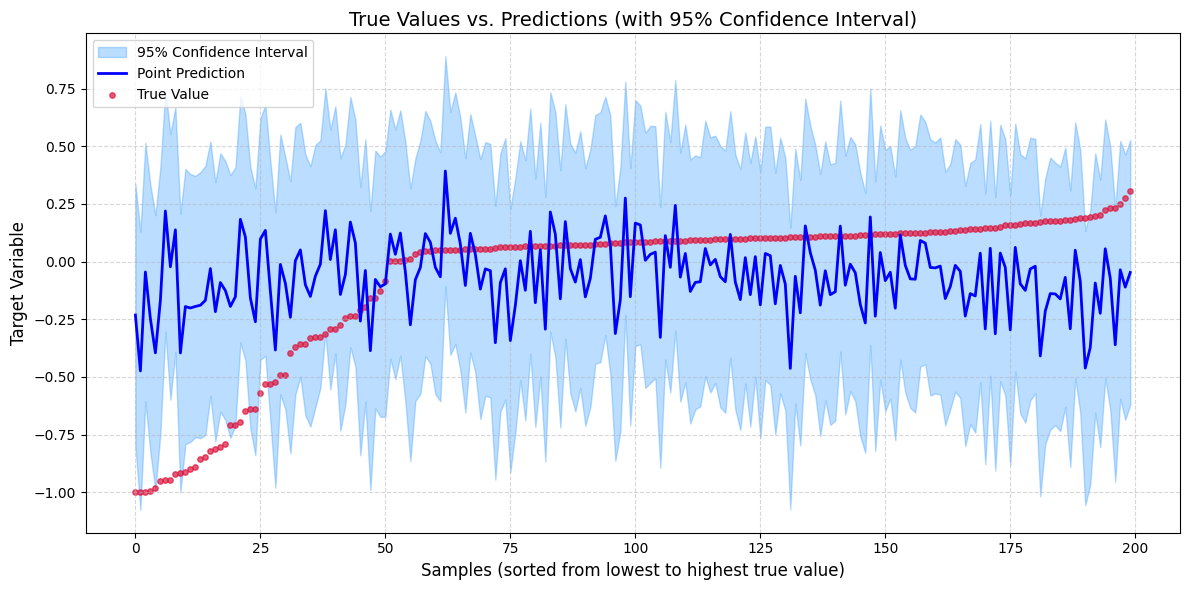

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

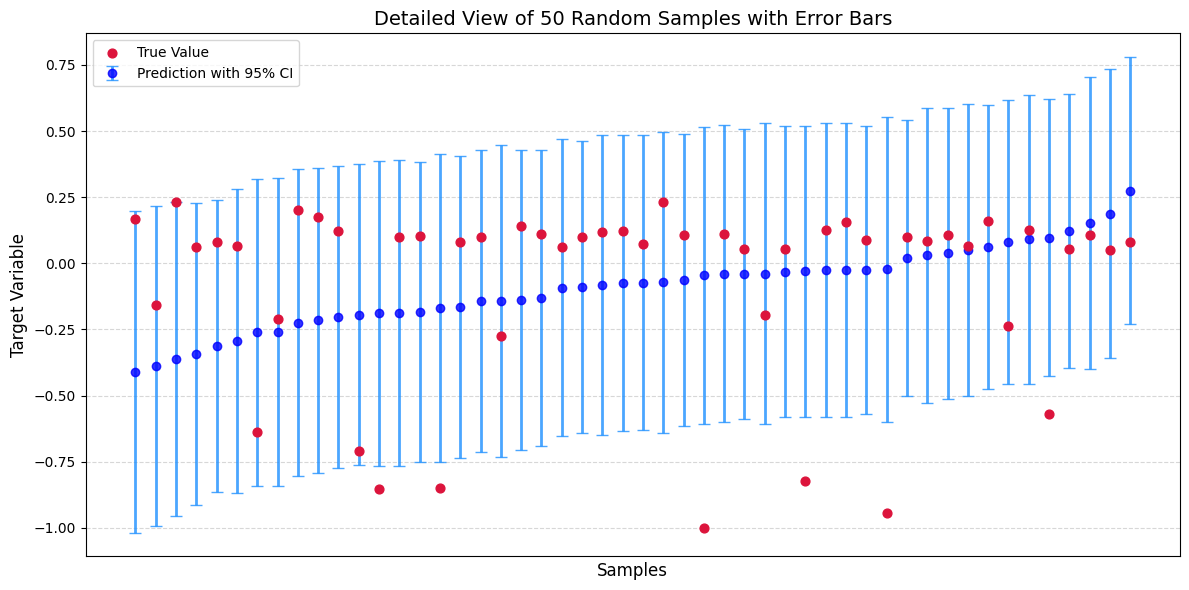

In [ ]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 10k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble


# Parameter tuning settings

timeout_seconds = 60*60*1
no_improvement_trials = 100

# Split the 10k dataset to evaluate on holdout after tuning

X_tuning = train_10k_X.head(8000)
y_tuning = train_10k_y_reg.head(8000)
X_val_holdout = train_10k_X.tail(2000)
y_val_holdout = train_10k_y_reg.tail(2000)

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 8), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        preds_dist = full_pipeline.named_steps['histgradientboostingregressor'].sample(preds_point, preds_std, n_estimates=1000)
        
        crps = crps_ensemble(preds_dist, y_val.values)
        cv_scores.append(crps)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST CRPS: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_10k_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_10k_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_10k_parallel.html")


[I 2026-04-23 21:56:31,119] A new study created in memory with name: no-name-dc5e1d3f-d0c0-484b-ae47-3dad3a5cc192
[I 2026-04-23 21:56:43,471] Trial 5 finished with value: 0.2981007197095523 and parameters: {'max_iter': 324, 'learning_rate': 0.018094229408000605, 'max_depth': 2, 'min_samples_leaf': 35, 'max_features': 0.38112321528942766, 'max_leaf_nodes': 18, 'l2_regularization': 0.008837154806842915, 'max_bins': 148}. Best is trial 5 with value: 0.2981007197095523.
[I 2026-04-23 21:56:51,993] Trial 4 finished with value: 0.303005021366328 and parameters: {'max_iter': 502, 'learning_rate': 0.06478957931711249, 'max_depth': 2, 'min_samples_leaf': 15, 'max_features': 0.5547570546709562, 'max_leaf_nodes': 13, 'l2_regularization': 0.0010934466249352445, 'max_bins': 70}. Best is trial 5 with value: 0.2981007197095523.
[I 2026-04-23 21:56:59,437] Trial 1 finished with value: 0.2986973313645337 and parameters: {'max_iter': 689, 'learning_rate': 0.022698593237437035, 'max_depth': 2, 'min_sampl


BEST RMSE: 0.2981
BEST PARAMETERS:
best_params = {
    "max_iter": 324,
    "learning_rate": 0.018094229408000605,
    "max_depth": 2,
    "min_samples_leaf": 35,
    "max_features": 0.38112321528942766,
    "max_leaf_nodes": 18,
    "l2_regularization": 0.008837154806842915,
    "max_bins": 148,
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.6706
  max_bins            : 0.1336
  max_leaf_nodes      : 0.0477
  l2_regularization   : 0.0412
  max_features        : 0.0376
  max_iter            : 0.0348
  min_samples_leaf    : 0.0187
  max_depth           : 0.0159


In [ ]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
best_params["max_iter"] = int(best_params["max_iter"] * 2)
best_params["learning_rate"] = best_params["learning_rate"] / 2
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val CRPS:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)


Optuna Val RMSE:   0.2981
Holdout Test RMSE: 0.3135


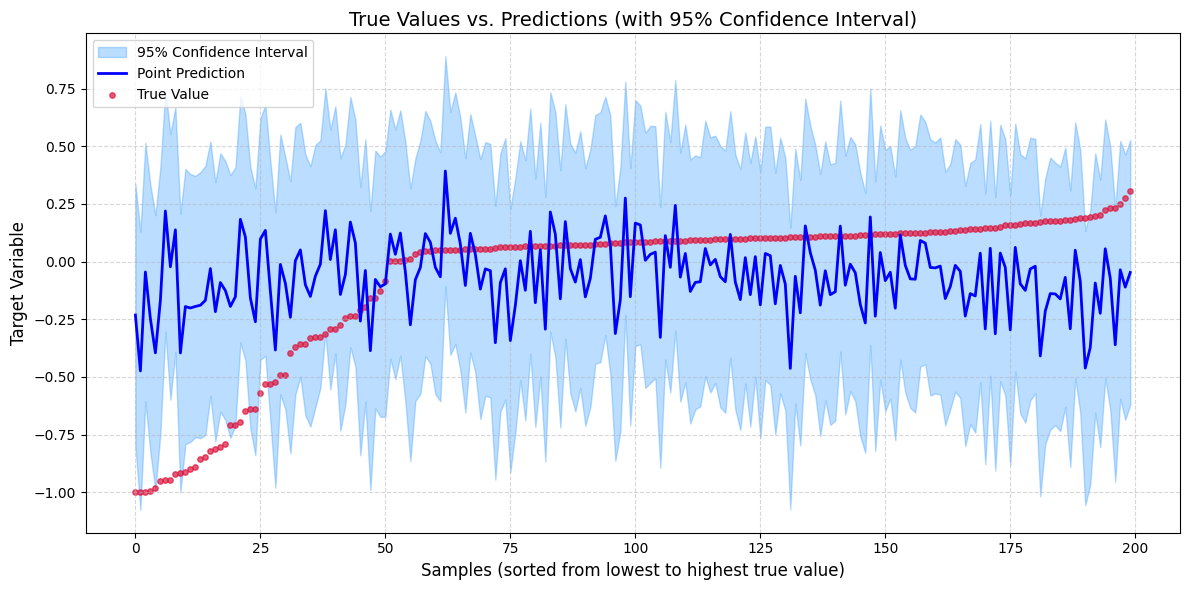

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

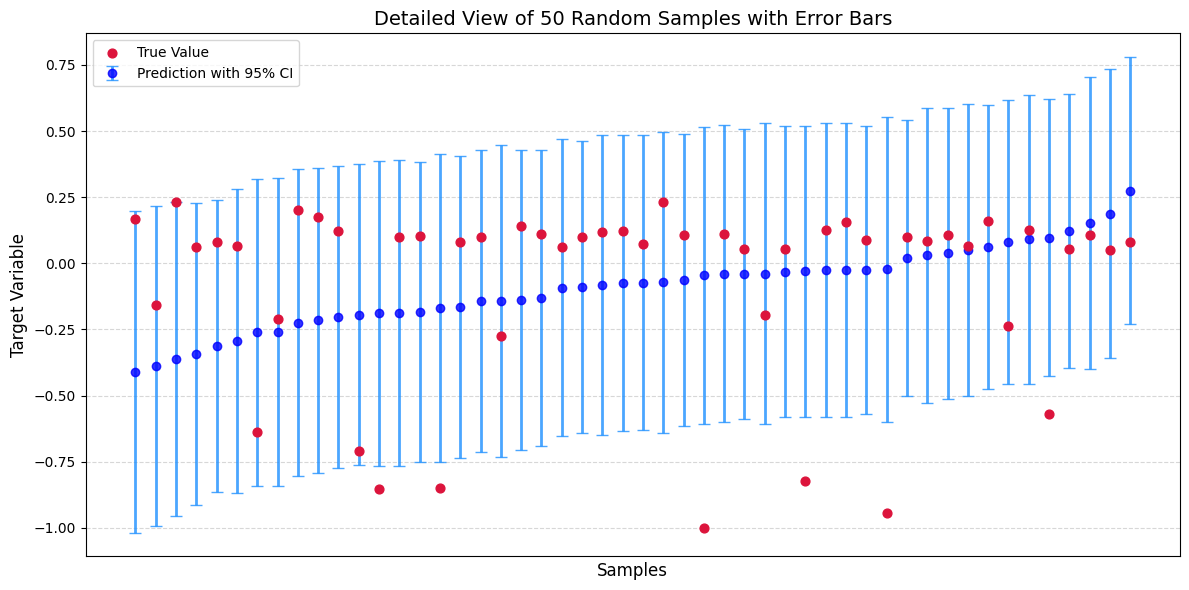

In [ ]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 100k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble


# Parameter tuning settings

timeout_seconds = 60*60*3
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

X_tuning = train_100k_X.head(80000)
y_tuning = train_100k_y_reg.head(80000)
X_val_holdout = train_100k_X.tail(20000)
y_val_holdout = train_100k_y_reg.tail(20000)

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 20), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        preds_dist = full_pipeline.named_steps['histgradientboostingregressor'].sample(preds_point, preds_std, n_estimates=1000)
        
        crps = crps_ensemble(preds_dist, y_val.values)
        cv_scores.append(crps)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST CRPS: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_100k_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_100k_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_100k_parallel.html")

[I 2026-04-23 21:57:57,026] A new study created in memory with name: no-name-2c1cf784-9844-495f-bbf5-d6c7401ac779


In [ ]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
best_params["max_iter"] = int(best_params["max_iter"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val CRPS:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)


Optuna Val AUC:   0.7093
Holdout Test AUC: 0.7124


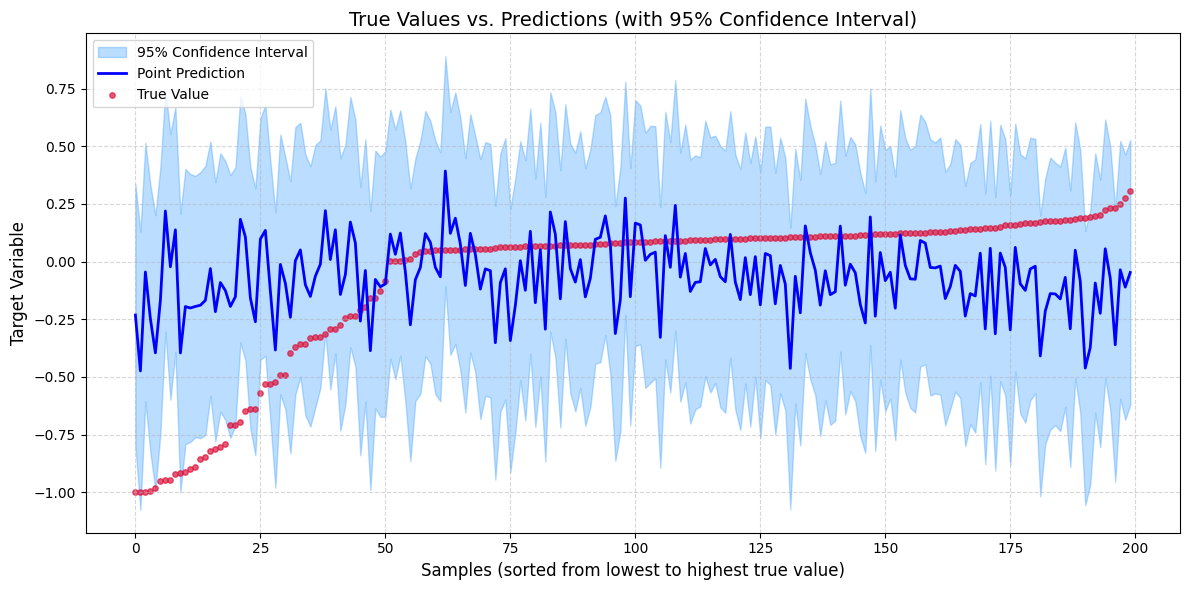

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

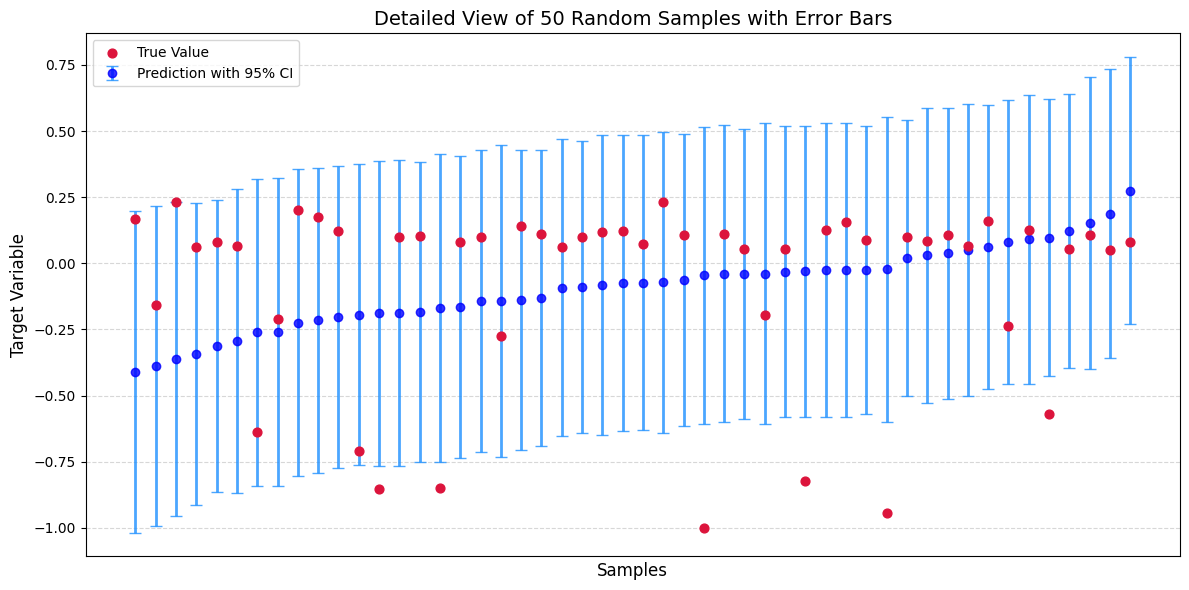

In [ ]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Whole training data set

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble


# Parameter tuning settings

timeout_seconds = 60*60*4
no_improvement_trials = 100

split_index = int(len(train_full_X) * 0.8)

X_tuning = train_full_X[:split_index]
y_tuning = train_full_y_reg[:split_index]
X_val_holdout = train_full_X[split_index:]
y_val_holdout = train_full_y_reg[split_index:]

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 20), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        preds_dist = full_pipeline.named_steps['histgradientboostingregressor'].sample(preds_point, preds_std, n_estimates=1000)
        
        crps = crps_ensemble(preds_dist, y_val.values)
        cv_scores.append(crps)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST CRPS: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_full_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_full_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_full_parallel.html")

[I 2026-04-23 18:24:58,049] A new study created in memory with name: no-name-f4e10f02-edf5-4bf8-b2cc-71b91b25ea1d
[W 2026-04-23 18:25:01,167] Trial 7 failed with parameters: {'max_iter': 143, 'learning_rate': 0.013715578216161832, 'max_depth': 10, 'min_samples_leaf': 31, 'max_features': 0.7860584571322597, 'max_leaf_nodes': 372, 'l2_regularization': 79.84647563521074, 'max_bins': 420} because of the following error: InvalidParameterError("The 'max_bins' parameter of HistGradientBoostingClassifier must be an int in the range [2, 255]. Got 420 instead.").
Traceback (most recent call last):
  File "/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktická část/Github/bachelor_thesis/.venv/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_82703/3160472742.py", line 59, in objective_histgbm
    full_pipeline.fit(X_tr, y_tr)
  File "/Users/oskarklima/Documents

KeyboardInterrupt: 

[I 2026-04-23 18:28:35,292] Trial 0 finished with value: 0.7348398789598615 and parameters: {'max_iter': 318, 'learning_rate': 0.03619179931386752, 'max_depth': 19, 'min_samples_leaf': 102, 'max_features': 0.895964581643484, 'max_leaf_nodes': 14, 'l2_regularization': 0.0013100115943084365, 'max_bins': 108}. Best is trial 0 with value: 0.7348398789598615.
[I 2026-04-23 18:30:20,176] Trial 2 finished with value: 0.7191617074511787 and parameters: {'max_iter': 607, 'learning_rate': 0.0013737458799797147, 'max_depth': 4, 'min_samples_leaf': 414, 'max_features': 0.6080603549763262, 'max_leaf_nodes': 420, 'l2_regularization': 90.77656462366532, 'max_bins': 215}. Best is trial 0 with value: 0.7348398789598615.
[I 2026-04-23 18:33:44,750] Trial 4 finished with value: 0.7338305409935048 and parameters: {'max_iter': 821, 'learning_rate': 0.00934961791633918, 'max_depth': 5, 'min_samples_leaf': 364, 'max_features': 0.8466727822970896, 'max_leaf_nodes': 212, 'l2_regularization': 0.0013315468221556

In [ ]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
best_params["max_iter"] = int(best_params["max_iter"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val CRPS:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

Optuna Val AUC: 0.7566
Holdout Test AUC: 0.7298


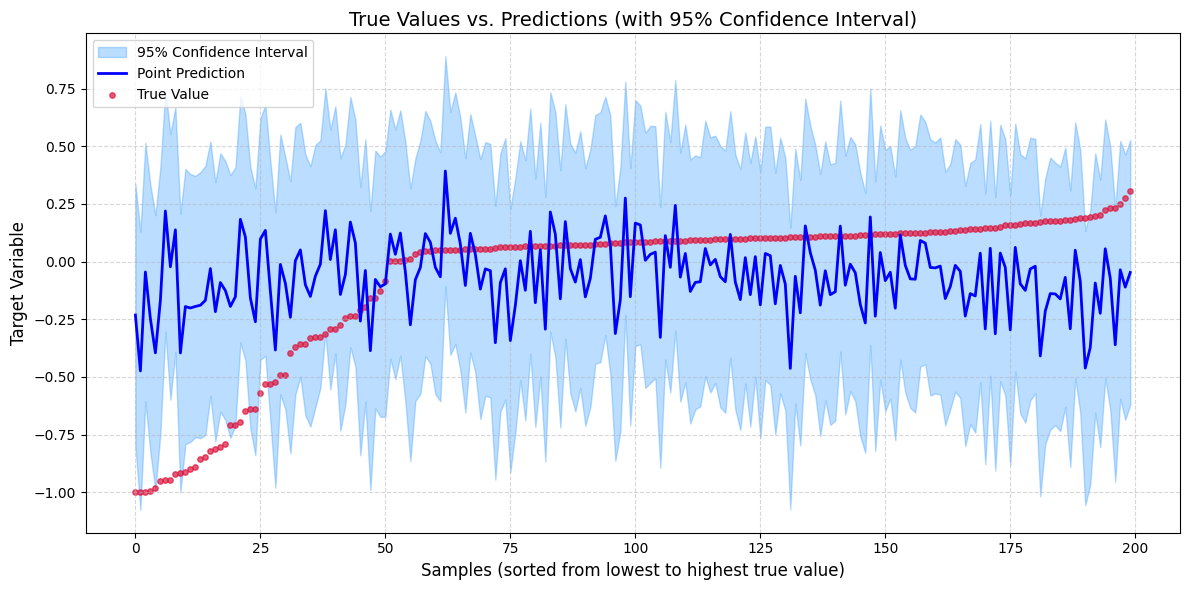

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

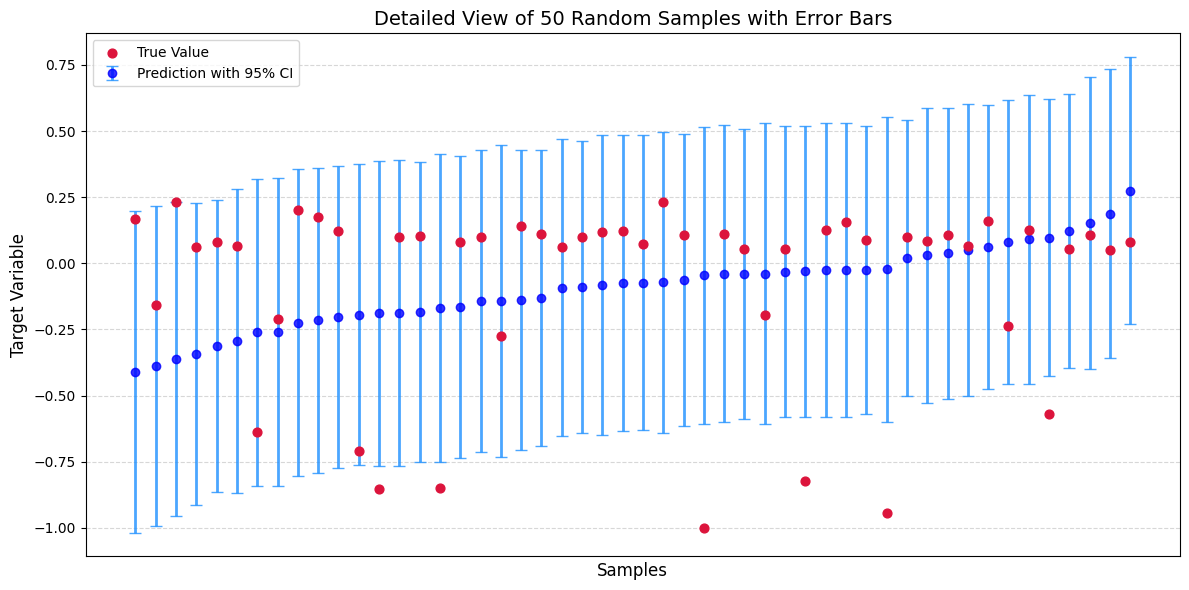

In [ ]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()